# 1. Preparation



## 1.1 Prepare environment

In [ ]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi

Fri Sep  4 13:02:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   41C    P8             16W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install torchinfo torchview

In [ ]:
import sys
print( f"Python {sys.version}\n" )

import random
import time

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# Summarize parameters of each layer
import torchinfo
print( f"torchinfo {torchinfo.__version__}\n" )

# Visually outline layers, their connections, and their corresponding tensor shapes
import torchview
print( f"torchview {torchview.__version__}\n" )

# https://docs.pytorch.org/vision/0.21/transforms.html
import torchvision
print( f"torchvision {torchvision.__version__}" )
import torchvision.transforms.v2 as T

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")

        # Important: The CUDA version in "nvidia-smi" must be equal or higher than "torch.version.cuda".
        # If they mismatch, it may cause silent hangs during heavy CUDA operations.
        # In that case, reinstall PyTorch from pytorch.org with the correct CUDA version.
        print(f"   |- {torch.version.cuda = }")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]

NumPy 2.1.3

torchinfo 1.8.0

torchview 0.2.7

torchvision 0.26.0+cu128
PyTorch 2.11.0+cu128
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- torch.version.cuda = '12.8'
   |- CUDA GPU 0: NVIDIA L4


## 1.2 Prepare global variables/functions

In [ ]:
# Detect GPU (CUDA), Apple Silicon (MPS), or fallback to CPU
# 'device' is a scalar flag, not a tensor
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# This is the version of VGG16 weights that we will use throughout this example
VGG_WEIGHTS = torchvision.models.VGG16_Weights.IMAGENET1K_V1

# 2. Prepare the CIFAR-10 dataset

## 2.1 Preview the train dataset (Optional)

In [ ]:
# Load the data (Simple conversion to PyTorch Image)
# Be patient, this downloading step takes time (~30 minutes) in Colab
dataset = torchvision.datasets.CIFAR10( root='./data', train=True,
                                        download=True,
                                        transform=T.ToImage() )

100%|██████████| 170M/170M [30:41<00:00, 92.6kB/s]


In [ ]:
# Get a small batch (e.g., 12 images)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=12, shuffle=True)
images, labels = next(iter(dataloader))
print(f"\n==== CIFAR-10 ====")
print(f"images: {type(images)} , {images.shape} , {images.dtype} , [{torch.min(images)} , {torch.max(images)}]")
print(f"labels: {type(labels)} , {labels.shape} , {labels.dtype} , [{torch.min(labels)} , {torch.max(labels)}] ")

# Get the class names
cifar10_class_names = dataset.classes
print(f"classes: {cifar10_class_names}")


==== CIFAR-10 ====
images: <class 'torch.Tensor'> , torch.Size([12, 3, 32, 32]) , torch.uint8 , [0 , 255]
labels: <class 'torch.Tensor'> , torch.Size([12]) , torch.int64 , [3 , 9] 
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


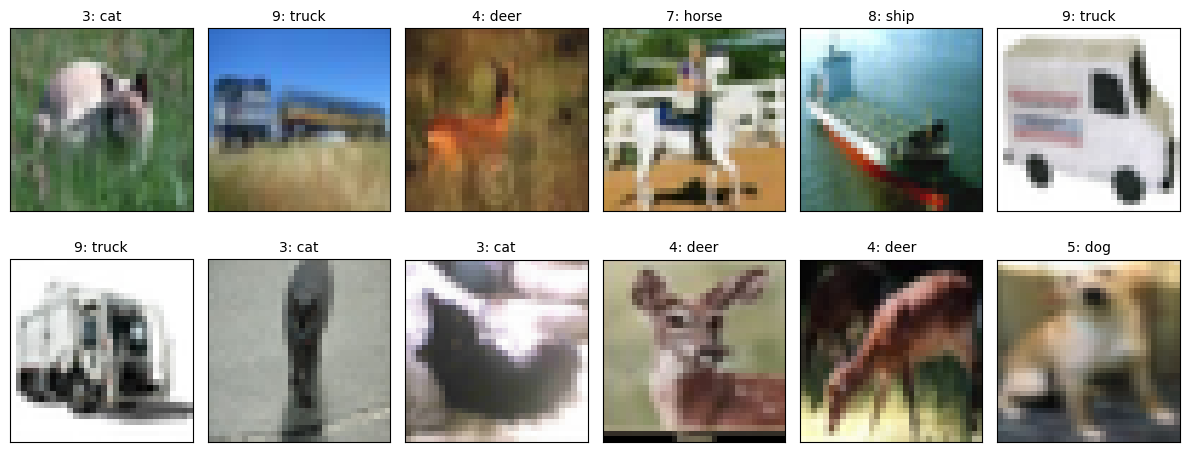

In [ ]:
# Show image examples
fig = plt.figure(figsize=(12, 5))
cifar10_class_names = dataset.classes

for i in range(len(images)):
    ax = fig.add_subplot(2, 6, i + 1, xticks=[], yticks=[])

    # Convert from (C, H, W) to (H, W, C) for plotting
    img = images[i].permute(1, 2, 0)
    plt.imshow(img)

    # Set title: "Index: Name" (e.g., "3: cat")
    ax.set_title(f"{labels[i].item()}: {cifar10_class_names[labels[i]]}", fontsize=10)

plt.tight_layout()
plt.show()

## 2.2 Load the dataset (with transformation)

**Preprocessing a pre-trained VGG16 backbone for CIFAR-10**

- <font color=#0E9594>**Use ImageNet stats, not CIFAR-10 stats:** The pretrained filters were calibrated to expect inputs in ImageNet distribution; feeding a different one detunes the very features we're trying to reuse.</font>

    > <font color=#0E9594>**Rule of thumb:** Always match the original training preprocessing of a pre-trained model, regardless of the new dataset. The backbone only sees numbers, it doesn't know where they came from.</font>

- **Even with full fine-tuning** (fine-tune all layers in the VGG16 backbone), there's no benefit to switching to CIFAR-10 stats. We'd be discarding free, correct calibration at the start for no gain. For VGG16 backbone, ImageNet stats remain the right default whether we freeze the backbone or fine-tune the whole network.

- **Resize CIFAR-10 images (32×32) to 224×224** before normalizing.
    - VGG16 has 5 max-pool layers (each halving spatial size); at 32×32 input that collapses to ~1×1 before the classifier, destroying spatial structure the conv layers depend on.
    - The pretrained filters expect to progressively extract features across a large receptive field; collapsing to ~1×1 early starves them of the spatial structure they were trained to operate on, so accuracy suffers even though the code runs fine.
    - Because `torchvision`'s VGG16 uses `AdaptiveAvgPool` (more detail in Section 3) before the classifier, it won't error on a 32×32 input. But `AdaptiveAvgPool` only fixes the final shape mismatch, not the loss of spatial information that already happened in the conv layers upstream.

    > ℹ️ <font color=#0E9594>This "augment small → resize up" order applies specifically when our images are smaller than the backbone's expected input.</font>

    > ℹ️ <font color=#0E9594>When images are larger than the target size, the correct approach is the opposite.</font> Directly resizing every training image to a fixed square (e.g., `Resize((224, 224))`) results in the same deterministic crop every epoch and distorts aspect ratio. The classic ImageNet-style pipeline is:
    > 1. Resize down to a size slightly bigger than the target (e.g., resize the shorter side to 256 with `Resize(256)`). This puts every image on the same physical scale first and still leaves some room for cropping.
    > 2. Then apply `RandomCrop(224)` for training or `CenterCrop(224)` for val/test. Note that the pipeline does not crop directly on the full image (without first resizing) as it would give wildly inconsistent "zoom levels." Also, cropping cannot be applied if images are already smaller than the crop size.

In [ ]:
# Pull the exact preprocessing that our target VGG16 was pretrained with
preprocess = VGG_WEIGHTS.transforms()

# Inspect what it actually does (resize size + normalization stats)
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
IMAGENET_MEAN = preprocess.mean
IMAGENET_STD = preprocess.std
RESIZE_SIZE = 224  # matches VGG16's expected input

# --- TRAINING ---
# Augmentation (on small 32x32 image) -> Resize -> Normalize
train_transform = T.Compose([
    # 1. Convert to image tensor (no scaling)
    T.ToImage(),

    # 2. Augment at native CIFAR-10 size (32x32)
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),

    # 3. Upscale to VGG16's expected size
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),

    # 4. Convert to Float and scale [0, 255] to [0, 1]
    T.ToDtype(torch.float32, scale=True),

    # 5. Normalize with ImagetNet stat as expected by VGG16 backbone
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_transform

Compose(
      ToImage()
      RandomCrop(size=(32, 32), padding=[4, 4, 4, 4], pad_if_needed=False, fill=0, padding_mode=constant)
      RandomHorizontalFlip(p=0.5)
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [ ]:
#--- TESTING (No augmentation) ---

# Option 1: Reuse VGG16's preprocess
# |-> ResizeShortSideTo(256) → CenterCrop(224) → ToTensor → ImageNet Normalize
test_transform = preprocess

# Option 2: Manual implementation
# |-> Resize((224, 224)) → ToTensor → ImageNet Normalize
test_transform = T.Compose([
    T.ToImage(),
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# For this example, we use Option 2.
# "ResizeShortSideTo(256) → CenterCrop(224)" logic exists to handle variable-sized non-square photos.
# CIFAR-10 images are all square, so there's no aspect-ratio distortion to worry about.
# Option 2 omits the unnecessary cropping step.
test_transform

Compose(
      ToImage()
      Resize(size=[224, 224], interpolation=InterpolationMode.BILINEAR, antialias=True)
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)

In [ ]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
print(f"Train Dataset Size: {len(train_set)}")
sample_img, sample_label = train_set[0]
print(f"|- Object type: {type(sample_img)}")   # PIL Image
print(f"|- Image Shape: {sample_img.shape}")   # (28, 28)
print(f"|- Pixel Range (Min/Max): {torch.min(sample_img)}, {torch.max(sample_img)}")

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)
print(f"\nTest Dataset Size: {len(test_set)}")
sample_img, sample_label = test_set[0]
print(f"|- Object type: {type(sample_img)}")   # PIL Image
print(f"|- Image Shape: {sample_img.shape}")   # (28, 28)
print(f"|- Pixel Range (Min/Max): {torch.min(sample_img)}, {torch.max(sample_img)}")

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4)

Train Dataset Size: 50000
|- Object type: <class 'torchvision.tv_tensors._image.Image'>
|- Image Shape: torch.Size([3, 224, 224])
|- Pixel Range (Min/Max): -2.1179039478302, 2.393557548522949

Test Dataset Size: 10000
|- Object type: <class 'torchvision.tv_tensors._image.Image'>
|- Image Shape: torch.Size([3, 224, 224])
|- Pixel Range (Min/Max): -1.8952821493148804, 2.5877127647399902


# 3. Observe VGG16 alternatives (1000 output classes)

This example examines two versions of VGGs:
1. **The legacy/original version:** The original VGG uses a fixed-size flatten layer. So it is extremely heavy and <u>requires the input image to be exactly 224x224</u>.
    - **Key Feature:** `nn.Flatten()` $\rightarrow$ `nn.Linear(25088, 4096)`.
    - This is the "Brute Force" era. Massive memory usage, high risk of overfitting, but very high capacity.
2. **The `torchvision` version:** PyTorch adds an `AdaptiveAvgPool2d(7, 7)` before the heavy classifier.
    - **Key Feature:** `nn.AdaptiveAvgPool2d((7, 7))` $\rightarrow$ Original Classifier.
    - This is the "Flexibility" era. The model now accepts any image size, but it still keeps the massive, expensive 100-million-parameter head.


<div style="border-left: 6px solid #dd6b20; background-color: rgba(221, 107, 32, 0.15); padding: 12px 16px; border-radius: 0 8px 8px 0; margin: 10px 0;">

> ℹ️ **NOTE**
>
> In PyTorch, `AdaptiveAvgPool2d` is a specialized layer that allows our model to accept images of any resolution while keeping the output size constant.
>
> - In a traditional Pooling layer (like `MaxPool2d`), we define the sliding window (e.g., 2x2). The output size depends entirely on the input size.
> - In an adaptive Pooling layer, <u>we define the desired output size</u> (e.g., 7x7). The layer looks at the input and says, "Okay, to turn this $100 \times 100$ feature map into a 7x7, I need to use a pool window of roughly 14x14."

</div>






## 3.1 The `torchvision` version

In [ ]:
model = torchvision.models.vgg16(weights=VGG_WEIGHTS)
model

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 243MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       36,928
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       73,856
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       147,584
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      295,168
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      590,080
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      590,080
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      1,180,160
│    └─ReLU: 2-19                

In [ ]:
# Because of AdaptivePooling, input images of any resolution are fine
out1 = model(torch.randn(1, 3, 224, 224)) # Ok
out2 = model(torch.randn(1, 3, 300, 300)) # Ok

print(f"{out1.shape = }")
print(f"{out2.shape = }")

out1.shape = torch.Size([1, 1000])
out2.shape = torch.Size([1, 1000])


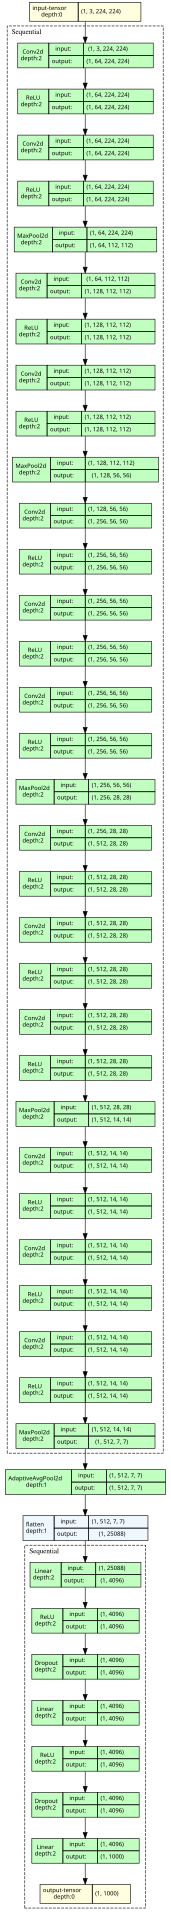

In [ ]:
model_graph = torchview.draw_graph(
    model=model,

    # Pass a list of tuples representing (Batch, Channels, H, W)
    input_size=[(1, 3, 224, 224)],
    expand_nested=True
)

# Save the graph to an image file
model_graph.visual_graph.render("CNN2_ex3_PytorchVGG_224", format="png")

# Show the graph in the output cell
model_graph.visual_graph

## 3.2 The legacy/original version

In [ ]:
class LegacyVGG(torch.nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()

        # Keep the pre-trained feature extractor
        self.features = torchvision.models.vgg16(weights=VGG_WEIGHTS).features

        # Original VGG didn't have AdaptivePool; it relied on exact input sizes
        self.classifier = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(512 * 7 * 7, 4096),
            torch.nn.ReLU(),
            torch.nn.Linear(4096, 4096),
            torch.nn.ReLU(),
            torch.nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
model = LegacyVGG()
model

LegacyVGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

In [ ]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
LegacyVGG                                --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       1,792
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       36,928
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       73,856
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       147,584
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      295,168
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      590,080
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      590,080
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      1,180,160
│    └─ReLU: 2-19                

In [ ]:
# The legacy VGG strictly requires an RGB image of 224x224 resolution
out1 = model(torch.randn(1, 3, 224, 224)) # Ok
out2 = model(torch.randn(1, 3, 300, 300)) # RuntimeError

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x41472 and 25088x4096)

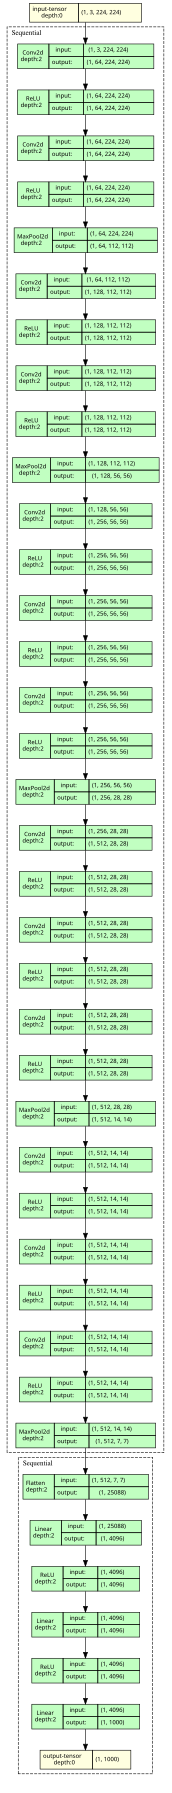

In [ ]:
model_graph = torchview.draw_graph(
    model=model,

    # Pass a list of tuples representing (Batch, Channels, H, W)
    input_size=[(1, 3, 224, 224)],
    expand_nested=True
)

# Save the graph to an image file
model_graph.visual_graph.render("CNN2_ex3_LegacyVGG_224", format="png")

# Show the graph in the output cell
model_graph.visual_graph

# 4. Create VGG16 with a custom classifier

- In this section, only the `torchvision`'s VGG16 (from Section 3.1) is used.

- There are several ways to adapt a pre-trained network (originally trained on ImageNet's 1000 classes) to a new dataset like CIFAR-10, which has only 10 classes. This example explores three straightforward options:
  1. Replace only the final output layer of the classifier + Freeze the entire backbone
  2. Replace the entire classifier block + Freeze the entire backbone
  3. Replace the entire classifier block + Unfreeze the final layer of the backbone

## 4.1 Replace only the final output layer of the classifier + Freeze the backbone

In [ ]:
# Load the base model
vgg1 = torchvision.models.vgg16(weights=VGG_WEIGHTS)

# Replace the last layer with our new output layer
vgg1.classifier[-1] = torch.nn.Linear(4096, 10)

vgg1

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Freeze all parameters in the model
# Tell PyTorch to exclude them from gradient computation during backpropagation to save memory and computation time
for param in vgg1.parameters():
    param.requires_grad = False

# Unfreeze only the parameters in the last layer
for param in vgg1.classifier[-1].parameters():
    param.requires_grad = True

In [ ]:
torchinfo.summary(vgg1)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       (1,792)
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       (36,928)
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       (73,856)
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       (147,584)
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      (295,168)
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      (590,080)
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      (590,080)
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      (1,180,160)
│    └─ReLU: 2-19

## 4.2 Replace the entire classifier block + Freeze the entire backbone

In [ ]:
# Load the base model
vgg2 = torchvision.models.vgg16(weights=VGG_WEIGHTS)

# Replace the whole classifier with one output layer
vgg2.classifier = torch.nn.Linear(25088, 10)

vgg2

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# Freeze all parameters in the model
# Tell PyTorch to exclude them from gradient computation during backpropagation to save memory and computation time
for param in vgg2.parameters():
    param.requires_grad = False

# Unfreeze the parameters in the classifier (only 1 layer here)
for param in vgg2.classifier.parameters():
    param.requires_grad = True

In [ ]:
torchinfo.summary(vgg2)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       (1,792)
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       (36,928)
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       (73,856)
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       (147,584)
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      (295,168)
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      (590,080)
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      (590,080)
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      (1,180,160)
│    └─ReLU: 2-19

## 4.3 Replace the entire classifier block + Unfreeze the final layer of the backbone

In [ ]:
# Deepcopy from 'vgg2' to ensure that 'vgg3' starts from the same architecture and weights
# This is just to emphasize how different training techniques result, despite of the initial weights

# Deep copy to vgg3
import copy
vgg3 = copy.deepcopy(vgg2)

vgg3

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
# --- VERIFICATION ---

# Verify that weights in 'vgg2' and 'vgg3' MUST be identical in value
weights_identical = all(
    torch.equal(p1, p2)
    for p1, p2 in zip(vgg2.parameters(), vgg3.parameters())
)
print(f"Weights are identical: {weights_identical}")

# Verify that they DO NOT share memory addresses
memory_independent = all(
    p1.data_ptr() != p2.data_ptr()
    for p1, p2 in zip(vgg2.parameters(), vgg3.parameters())
)
print(f"Memory pointers are distinct: {memory_independent}")

Weights are identical: True
Memory pointers are distinct: True


In [ ]:
# Freeze all parameters in the model
# Tell PyTorch to exclude them from gradient computation during backpropagation to save memory and computation time
for param in vgg3.parameters():
    param.requires_grad = False

# Unfreeze ONLY the parameters in the last conv2d layer of the backbone
for param in vgg3.features[28].parameters():
    param.requires_grad = True

# Unfreeze the parameters in the classifier (only 1 layer here)
for param in vgg3.classifier.parameters():
    param.requires_grad = True

In [ ]:
torchinfo.summary(vgg3)

Layer (type:depth-idx)                   Param #
VGG                                      --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       (1,792)
│    └─ReLU: 2-2                         --
│    └─Conv2d: 2-3                       (36,928)
│    └─ReLU: 2-4                         --
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       (73,856)
│    └─ReLU: 2-7                         --
│    └─Conv2d: 2-8                       (147,584)
│    └─ReLU: 2-9                         --
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      (295,168)
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      (590,080)
│    └─ReLU: 2-14                        --
│    └─Conv2d: 2-15                      (590,080)
│    └─ReLU: 2-16                        --
│    └─MaxPool2d: 2-17                   --
│    └─Conv2d: 2-18                      (1,180,160)
│    └─ReLU: 2-19

# 5. Train and visualize

## 5.1 Train loop

In [ ]:
# =================================================================
# TRAINING LOOP (Sample-Based Accumulation)
# =================================================================
def train_and_validate(model, train_loader, val_loader, device, epochs=5):

    model.to(device)

    # Only pass parameters that have 'requires_grad = True' to optimizer
    # This ensures the optimizer doesn't waste memory or computation on frozen weights
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()

    history = {'t_loss': [], 't_acc': [], 'v_loss': [], 'v_acc': []}
    train_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- TRAINING PHASE ---
        model.train()
        running_loss = 0.0
        correct_samples = 0
        samples_processed = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            current_batch_size = images.size(0) # Handle potential smaller final batch

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Accumulate loss multiplied by batch size to get total sample loss
            running_loss += loss.detach() * current_batch_size
            samples_processed += current_batch_size

            # Accumulate the number of correct predictions
            with torch.inference_mode():
                preds = outputs.detach().argmax(dim=1)
                correct_samples += (preds == labels).sum().item()

        avg_train_loss = running_loss.item() / samples_processed
        avg_train_acc = (correct_samples / samples_processed) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        v_running_loss = 0.0
        v_correct_samples = 0
        v_samples_processed = 0

        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                b_size = images.shape[0]

                outputs = model(images)
                loss = criterion(outputs, labels)

                v_running_loss += loss.item() * b_size
                preds = outputs.argmax(dim=1)
                v_correct_samples += (preds == labels).sum().item()
                v_samples_processed += b_size

        avg_v_loss = v_running_loss / v_samples_processed
        avg_v_acc = (v_correct_samples / v_samples_processed) * 100

        history['t_loss'].append(avg_train_loss)
        history['t_acc'].append(avg_train_acc)
        history['v_loss'].append(avg_v_loss)
        history['v_acc'].append(avg_v_acc)

        epoch_duration = time.time() - epoch_start
        print(f"Epoch {epoch+1} | Time: {epoch_duration:.4f}s | Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}% | Val Loss: {avg_v_loss:.4f} | Val Acc: {avg_v_acc:.2f}%")

    train_duration = time.time() - train_start
    print(f"\nTRAINING COMPLETE: {train_duration:.2f} seconds per {epochs} epochs ({train_duration / epochs:.2f}s / epoch)")
    return history

In [ ]:
print("Training the first custom model ...")

# --- Hardware-dependent training time ---
# NVIDIA L4 GPU (VRAM 22.5GB): ~149 seconds per epoch
history1 = train_and_validate(vgg1, train_loader, test_loader, device, epochs=15)

Training the first custom model ...
Epoch 1 | Time: 148.9516s | Train Loss: 1.0937 | Train Acc: 66.08% | Val Loss: 0.7140 | Val Acc: 76.88%
Epoch 2 | Time: 148.8404s | Train Loss: 0.7202 | Train Acc: 75.59% | Val Loss: 0.6268 | Val Acc: 78.49%
Epoch 3 | Time: 148.9163s | Train Loss: 0.6625 | Train Acc: 76.99% | Val Loss: 0.5941 | Val Acc: 79.43%
Epoch 4 | Time: 148.9302s | Train Loss: 0.6373 | Train Acc: 77.55% | Val Loss: 0.5692 | Val Acc: 80.20%
Epoch 5 | Time: 148.8911s | Train Loss: 0.6159 | Train Acc: 78.26% | Val Loss: 0.5570 | Val Acc: 80.66%
Epoch 6 | Time: 148.8652s | Train Loss: 0.6092 | Train Acc: 78.53% | Val Loss: 0.5514 | Val Acc: 80.95%
Epoch 7 | Time: 148.9233s | Train Loss: 0.5985 | Train Acc: 78.84% | Val Loss: 0.5409 | Val Acc: 81.20%
Epoch 8 | Time: 148.8214s | Train Loss: 0.5927 | Train Acc: 79.21% | Val Loss: 0.5354 | Val Acc: 81.44%
Epoch 9 | Time: 148.8566s | Train Loss: 0.5905 | Train Acc: 79.21% | Val Loss: 0.5282 | Val Acc: 81.57%
Epoch 10 | Time: 148.8377s |

In [ ]:
print("Training the second custom model ...")

# --- Hardware-dependent training time ---
# NVIDIA L4 GPU (VRAM 22.5GB): ~148 seconds per epoch
history2 = train_and_validate(vgg2, train_loader, test_loader, device, epochs=15)

Training the second custom model ...
Epoch 1 | Time: 147.6228s | Train Loss: 0.7144 | Train Acc: 78.11% | Val Loss: 0.4438 | Val Acc: 84.73%
Epoch 2 | Time: 147.4896s | Train Loss: 0.4549 | Train Acc: 84.98% | Val Loss: 0.3907 | Val Acc: 86.28%
Epoch 3 | Time: 147.4689s | Train Loss: 0.4058 | Train Acc: 86.52% | Val Loss: 0.3791 | Val Acc: 86.61%
Epoch 4 | Time: 147.4795s | Train Loss: 0.3747 | Train Acc: 87.42% | Val Loss: 0.3660 | Val Acc: 87.16%
Epoch 5 | Time: 147.4776s | Train Loss: 0.3585 | Train Acc: 87.68% | Val Loss: 0.3604 | Val Acc: 87.53%
Epoch 6 | Time: 147.4292s | Train Loss: 0.3442 | Train Acc: 88.32% | Val Loss: 0.3567 | Val Acc: 87.72%
Epoch 7 | Time: 147.5608s | Train Loss: 0.3310 | Train Acc: 88.82% | Val Loss: 0.3526 | Val Acc: 87.73%
Epoch 8 | Time: 147.4733s | Train Loss: 0.3214 | Train Acc: 89.04% | Val Loss: 0.3528 | Val Acc: 87.92%
Epoch 9 | Time: 147.4584s | Train Loss: 0.3124 | Train Acc: 89.13% | Val Loss: 0.3513 | Val Acc: 88.10%
Epoch 10 | Time: 147.5779s 

In [ ]:
print("Training the third custom model ...")

# --- Hardware-dependent training time ---
# NVIDIA L4 GPU (VRAM 22.5GB): ~150 seconds per epoch
history3 = train_and_validate(vgg3, train_loader, test_loader, device, epochs=15)

Training the third custom model ...
Epoch 1 | Time: 150.8289s | Train Loss: 0.5744 | Train Acc: 80.52% | Val Loss: 0.3814 | Val Acc: 86.73%
Epoch 2 | Time: 150.4378s | Train Loss: 0.3727 | Train Acc: 87.08% | Val Loss: 0.3252 | Val Acc: 88.80%
Epoch 3 | Time: 150.4292s | Train Loss: 0.3149 | Train Acc: 89.30% | Val Loss: 0.3267 | Val Acc: 89.04%
Epoch 4 | Time: 150.5376s | Train Loss: 0.2770 | Train Acc: 90.43% | Val Loss: 0.3292 | Val Acc: 88.83%
Epoch 5 | Time: 150.5686s | Train Loss: 0.2470 | Train Acc: 91.46% | Val Loss: 0.3149 | Val Acc: 89.27%
Epoch 6 | Time: 150.4734s | Train Loss: 0.2201 | Train Acc: 92.39% | Val Loss: 0.3009 | Val Acc: 90.07%
Epoch 7 | Time: 150.4677s | Train Loss: 0.2027 | Train Acc: 93.17% | Val Loss: 0.3033 | Val Acc: 90.21%
Epoch 8 | Time: 150.4726s | Train Loss: 0.1815 | Train Acc: 93.83% | Val Loss: 0.3004 | Val Acc: 90.22%
Epoch 9 | Time: 150.4311s | Train Loss: 0.1669 | Train Acc: 94.36% | Val Loss: 0.2886 | Val Acc: 90.63%
Epoch 10 | Time: 150.4259s |

## 5.2 Learning curve visualization

In [ ]:
def plot_learning_curves(vgg1_h, vgg2_h, vgg3_h):
    epochs = range(1, len(vgg1_h['t_loss']) + 1)
    fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharey='row')

    # --- VGG1 Loss ---
    ax[0, 0].plot(epochs, vgg1_h['t_loss'], 'b-', label='VGG1 Training Loss (approx)')
    ax[0, 0].plot(epochs, vgg1_h['v_loss'], 'b--', label='VGG1 Validation Loss')
    ax[0, 0].set_title('VGG1: Training vs Validation Loss')
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # --- VGG2 Loss ---
    ax[0, 1].plot(epochs, vgg2_h['t_loss'], 'r-', label='VGG2 Training Loss (approx)')
    ax[0, 1].plot(epochs, vgg2_h['v_loss'], 'r--', label='VGG2 Validation Loss')
    ax[0, 1].set_title('VGG2: Training vs Validation Loss')
    ax[0, 1].legend()
    ax[0, 1].grid(True)

     # --- VGG3 Loss ---
    ax[0, 2].plot(epochs, vgg3_h['t_loss'], 'g-', label='VGG3 Training Loss (approx)')
    ax[0, 2].plot(epochs, vgg3_h['v_loss'], 'g--', label='VGG3 Validation Loss')
    ax[0, 2].set_title('VGG3: Training vs Validation Loss')
    ax[0, 2].legend()
    ax[0, 2].grid(True)

    # --- VGG1 Accuracy ---
    ax[1, 0].plot(epochs, vgg1_h['t_acc'], 'b-', label='VGG1 Training Acc (approx)')
    ax[1, 0].plot(epochs, vgg1_h['v_acc'], 'b--', label='VGG1 Validation Acc')
    ax[1, 0].set_title('VGG1: Training vs Validation Accuracy')
    ax[1, 0].legend()
    ax[1, 0].grid(True)

    # --- VGG2 Accuracy ---
    ax[1, 1].plot(epochs, vgg2_h['t_acc'], 'r-', label='VGG2 Training Acc (approx)')
    ax[1, 1].plot(epochs, vgg2_h['v_acc'], 'r--', label='VGG2 Validation Acc')
    ax[1, 1].set_title('VGG2: Training vs Validation Accuracy')
    ax[1, 1].legend()
    ax[1, 1].grid(True)

    # --- VGG3 Accuracy ---
    ax[1, 2].plot(epochs, vgg3_h['t_acc'], 'g-', label='VGG3 Training Acc (approx)')
    ax[1, 2].plot(epochs, vgg3_h['v_acc'], 'g--', label='VGG3 Validation Acc')
    ax[1, 2].set_title('VGG3: Training vs Validation Accuracy')
    ax[1, 2].legend()
    ax[1, 2].grid(True)

    plt.tight_layout()
    plt.show()

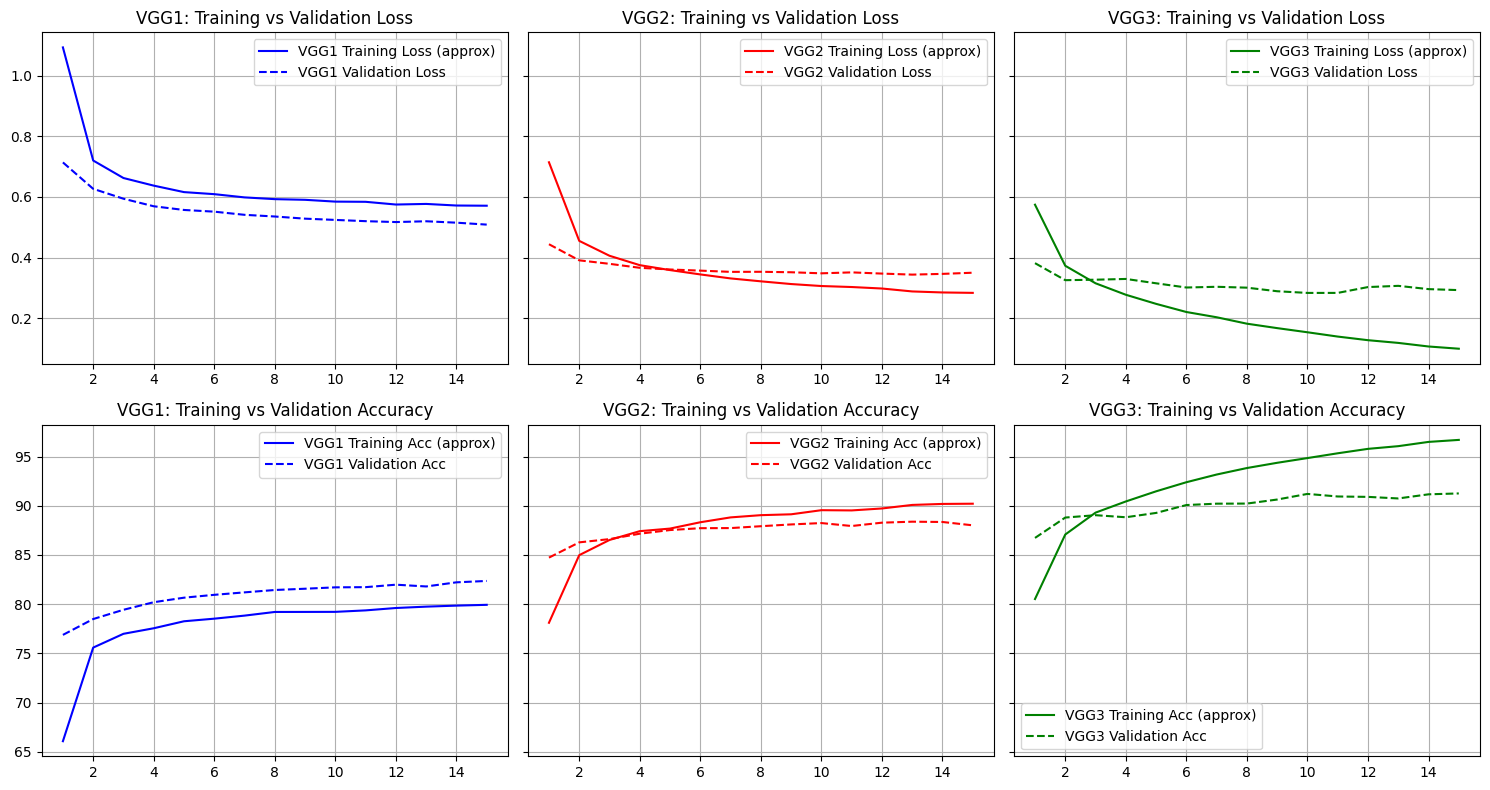

In [ ]:
plot_learning_curves(history1, history2, history3)

#### **Key reasons val performance can exceed train performance**

1. **Evaluation Timing:**
    - Training metrics are calculated as a running average across all batches within an epoch—starting from a less optimal state at batch 0.
    - Validation evaluates the model only once at the end of the epoch, when weights are fully updated for that cycle.
    - This discrepancy is most pronounced at the start of training, where weight updates per batch are largest.

2. **Data Augmentation:**
    - Augmentation transforms (e.g., random flips, rotations, color jitter) are applied exclusively to the training set to artificially increase sample difficulty.
    - During validation, the model evaluates clean, unaugmented inputs.
  
3. **Training Regularization:**
    - **Dropout:** Stochastic layers like `nn.Dropout` disable nodes during training (`model.train()`), reducing capacity. In validation (`model.eval()`), Dropout is turned off, allowing the network to use 100% of its parameters.
    - **L1 Regularization:** If manually added to the training loss function ($\text{Loss}_{\text{train}} + \lambda \sum \vert{}w\vert{}$), the L1 penalty inflates reported training loss. This penalty is usually omitted from the validation loss calculation.
    - **L2 Regularization:** Standard L2 weight decay via `optimizer.step()` does not inflate the scalar loss value, but constrains model capacity during optimization.

# 6. Evaluate on the test set

- For learning simplicity, this example uses the test set as the validation set. As a result, the final validation loss and accuracy match the test metrics.
- Please note that evaluating on the test set during training is strictly for demonstration purposes and <u>is not a recommended practice in real-world development, as it can lead to data leakage and biased model evaluation</u>.

# 7. Inference

In [ ]:
def visualize_test_results(model, device, title, start_from=0):
    """
    Visualizes a 4x5 grid of test results starting from a specific index.
    Displays global index, predicted label, and actual label.
    """
    model.eval()

    # 1. Select the specific range of 20 images using a Subset
    # We create a temporary loader for just these 20 samples
    num_images = 20 # 4 rows * 5 columns
    indices = list(range(start_from, start_from + num_images))
    subset = torch.utils.data.Subset(test_set, indices)
    temp_loader = torch.utils.data.DataLoader(subset, batch_size=num_images, shuffle=False)

    # 2. Get the data
    images, labels = next(iter(temp_loader))
    images, labels = images.to(device), labels.to(device)

    # 3. Forward pass
    with torch.inference_mode():
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        # Convert to probabilities for user viewing
        probs = torch.nn.functional.softmax(outputs, dim=1)

    # 4. Prepare CIFAR-10 images for display
    ## Reshape from [3,] to [1, 3, 1, 1] to match the [B, C, H, W] shape of the batch
    mean = torch.tensor(IMAGENET_MEAN).to(device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD).to(device).view(1, 3, 1, 1)
    ## Reverse the normalization
    images_denorm = (images * std) + mean
    ## Clamp ensures pixel values stay in [0,1] range
    images_denorm = torch.clamp(images_denorm, 0, 1)
    ## Change from [B, C, H, W] to [B, H, W, C]
    images_denorm = images_denorm.permute(0, 2, 3, 1)

    # 5. Setup the 4x5 Grid
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle(f"{title} (Starting from index {start_from})", fontsize=18, y=0.95)

    for i, ax in enumerate(axes.flat):
        # Calculate the global index for this specific image
        global_idx = start_from + i

        # Prepare image for plotting (C, H, W) -> (H, W, C)
        img = images_denorm[i].cpu().squeeze()
        ax.imshow(img)

        # Comparison logic for border color
        correct = (preds[i] == labels[i])
        color = 'green' if correct else 'red'

        # Apply thick colored borders to highlight errors
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)

        # Set title with Index, Prediction (P), and Actual (A)
        pred_idx = preds[i]
        ax.set_title(f"Idx: {global_idx} ({probs[i,pred_idx] * 100:.2f}%)\nPred: {pred_idx} ({cifar10_class_names[pred_idx]}) | True: {labels[i]} ({cifar10_class_names[labels[i]]})",
                     color=color, fontsize=10)

        # Clean up axes for better visibility
        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Adjust layout to fit main title
    plt.show()

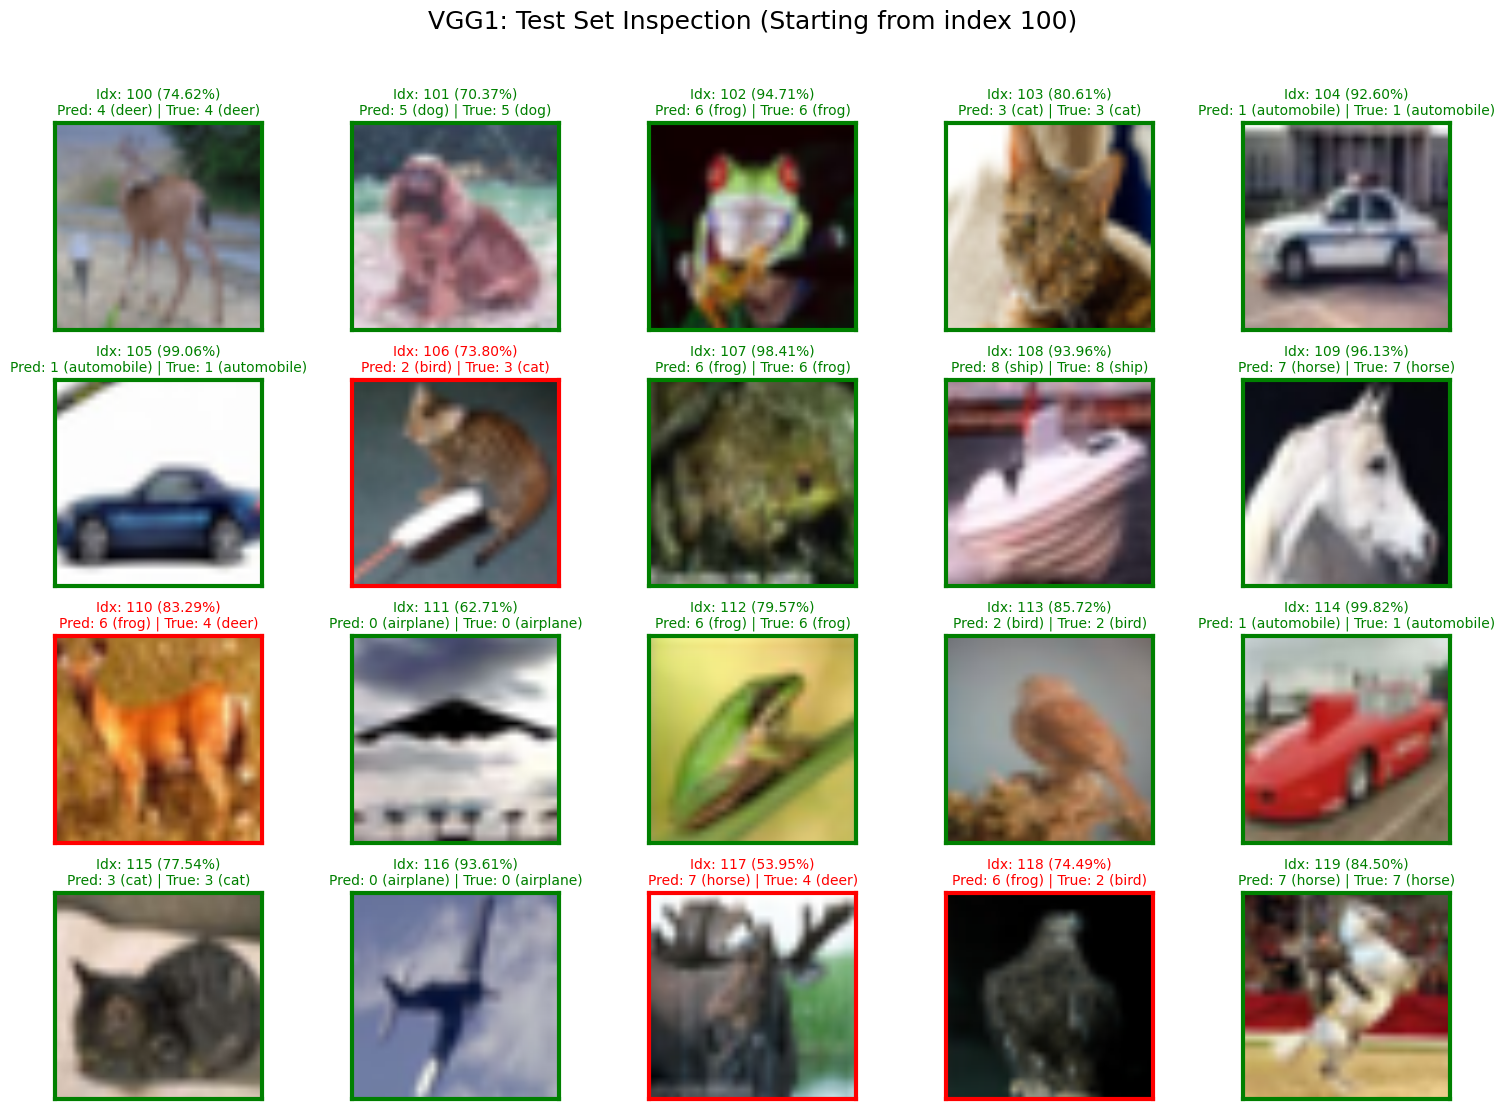

In [ ]:
visualize_test_results(vgg1, device, "VGG1: Test Set Inspection", start_from=100)

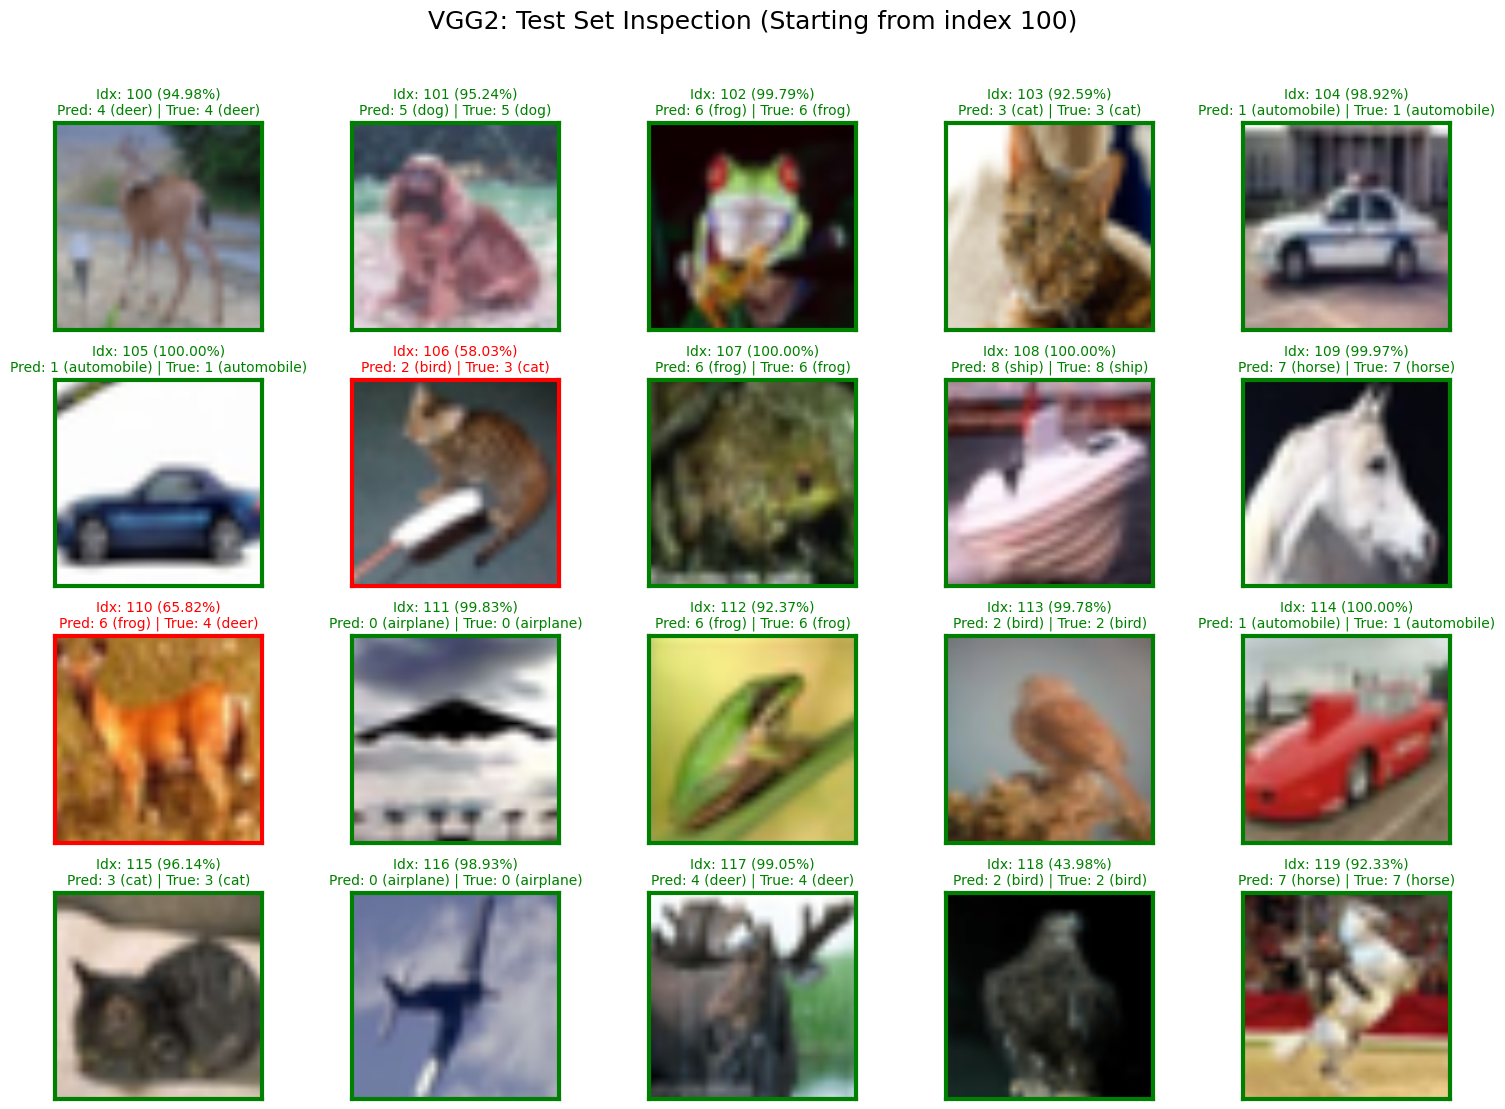

In [ ]:
visualize_test_results(vgg2, device, "VGG2: Test Set Inspection", start_from=100)

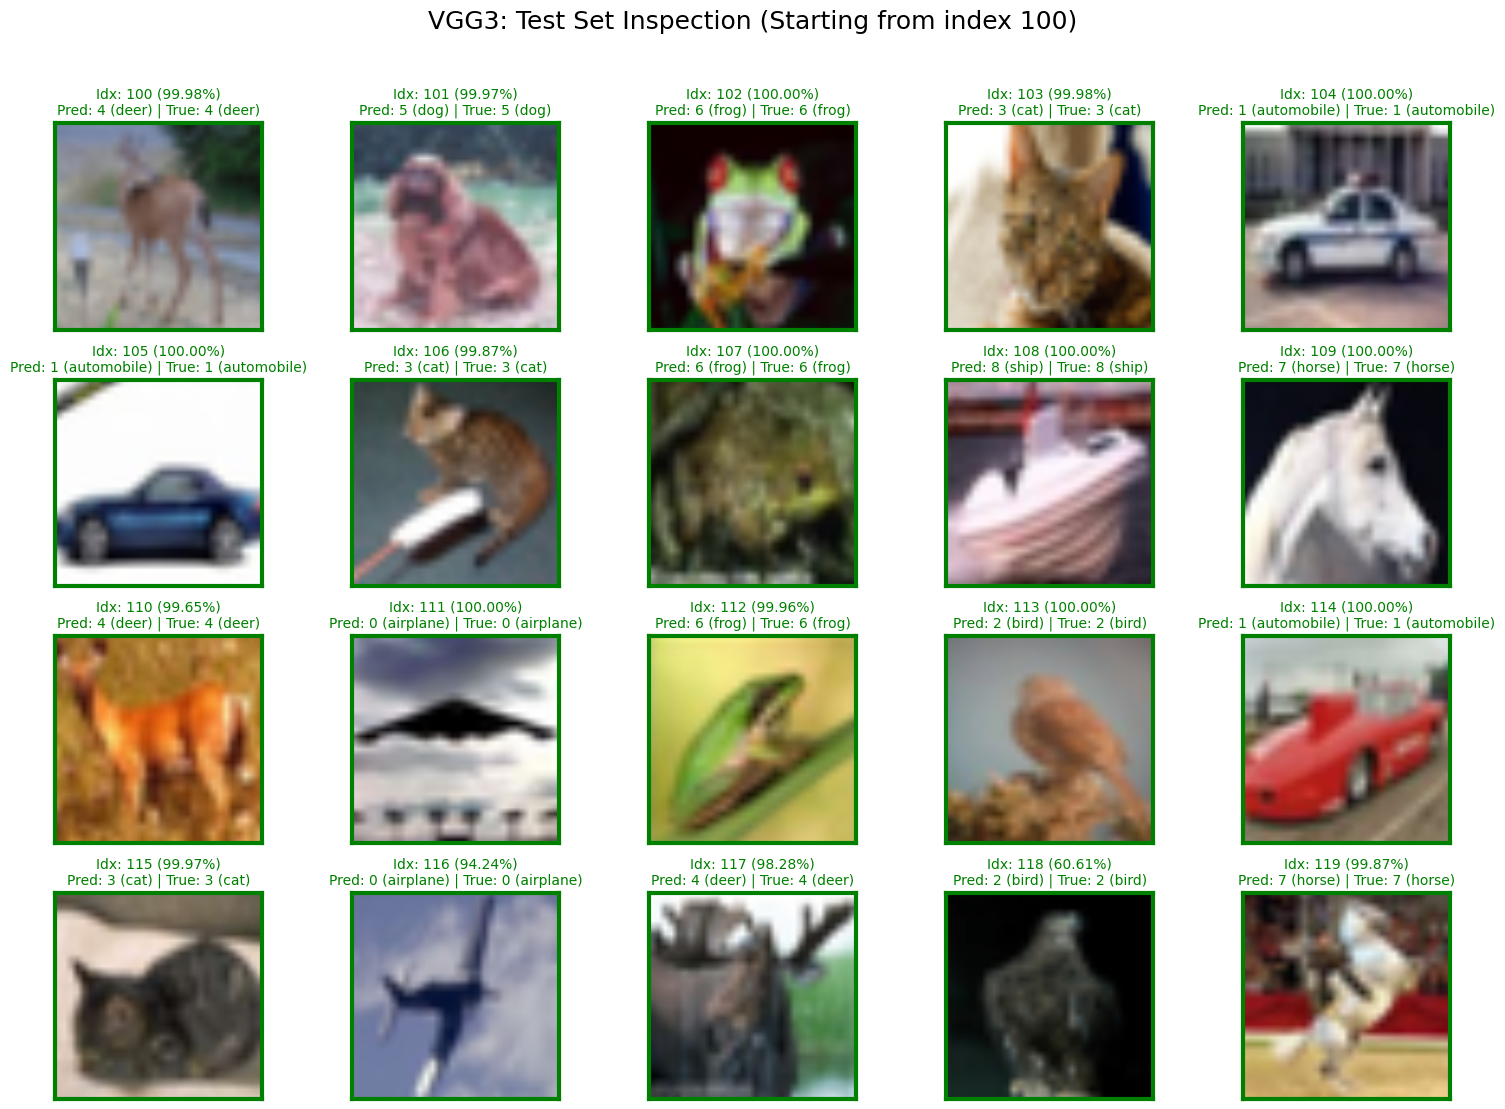

In [ ]:
visualize_test_results(vgg3, device, "VGG3: Test Set Inspection", start_from=100)

#### **Model Calibration** — why confidence ≠ correctness

- <font color=#0E9594>**Accuracy and confidence are related, but they measure different things.** Cross-entropy training encourages the model to assign higher probability to the correct class, but it does not guarantee that the predicted probabilities reflect the true likelihood of being correct.</font> A model can therefore be accurate yet overconfident or underconfident.

- **In a well-trained model, confidence and correctness are often associated.** Correct predictions, especially on clear in-distribution examples, tend to receive higher confidence, while difficult or ambiguous examples tend to receive lower confidence. However, this relationship is not guaranteed for individual predictions and does not by itself mean the model is well calibrated.

- **Modern deep nets trained with standard cross-entropy can be overconfident.** This phenomenon was prominently documented by Guo et al. 2017 (<a href="https://arxiv.org/abs/1706.04599">"On Calibration of Modern Neural Networks"</a>). Softmax probabilities can become very high even when predictions are wrong.

- **A wrong prediction can still get high confidence.** The model may strongly associate an input with the wrong class based on the features it has learned. <font color=#0E9594>High confidence therefore does not guarantee correctness.</font>

- **A correct prediction can still get low(ish) confidence.** <font color=#0E9594>Correct classification only requires the true class to receive the highest score; it does not require that score to be high.</font> Ambiguous or difficult inputs may receive substantial probability across several competing classes.

- **Training setup can affect calibration differently from accuracy:**

    - **Insufficient regularization** → can encourage overfitting and increasingly confident predictions.

    - **Long training / overfitting** → cross-entropy can continue decreasing by increasing the margin between the correct-class logit and competing logits even after training accuracy has saturated.

    - **Small dataset relative to model capacity** → increases the risk of overfitting and overly confident predictions that do not generalize.

- **Calibration is measurable and can often be improved separately from accuracy:**

    - **Temperature scaling** — post-hoc, divide logits by a learned positive scalar $T$ before softmax; this preserves class ranking and therefore classification accuracy while often improving calibration.

    - **Label smoothing during training** — discourages excessively peaked output distributions, though its effect on calibration is context-dependent.

    - **Reliability diagrams / Expected Calibration Error (ECE)** — commonly used to assess calibration by grouping predictions according to confidence and comparing confidence with actual accuracy in each group.

- **A 20-image sample isn't enough to diagnose calibration.** Assess calibration over the full test set using a reliability diagram and calibration metrics rather than judging individual examples.